# Optimization Report Code

### Pull and Prep Data

In [27]:
from gurobipy import *
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from math import sqrt

# User choices
TICKER = ["NVDA", "GOOG", "AVGO", "AAPL", "META"]
START  = "2025-01-01"
END    = "2025-12-31"

# Pull data
raw = yf.download(TICKER, start=START, end=END, auto_adjust=True, progress=False)

# Use adjusted close (adjusted via auto_adjust above)
df = raw["Close"].dropna().copy()
df.index = pd.to_datetime(df.index)

#percent daily returns
df = df.pct_change().dropna()

#view data structure
print(df.head())

#Portfolio components
stocks = df.columns
num_stocks=len(stocks)
print(f'Number of Stocks: {num_stocks}')
#expected return (mean)
stock_return = df.mean()
print(f'Expected Returns: {stock_return}')
#covariance matrix
cov_mat=df.cov()

Ticker          AAPL      AVGO      GOOG      META      NVDA
Date                                                        
2025-01-03 -0.002009  0.002457  0.013114  0.008995  0.044538
2025-01-06  0.006739  0.016599  0.025009  0.042290  0.034332
2025-01-07 -0.011388 -0.032867 -0.006314 -0.019533 -0.062170
2025-01-08  0.002023  0.002930 -0.006711 -0.011604 -0.000214
2025-01-10 -0.024104 -0.021805 -0.011362  0.008416 -0.029976
Number of Stocks: 5
Expected Returns: Ticker
AAPL    0.000681
AVGO    0.002256
GOOG    0.002239
META    0.000723
NVDA    0.001721
dtype: float64


## Portfolio Optimization

In [28]:
# Create an empty model
m = Model('portfolio')

# Add a variable for each stock
vars = pd.Series(m.addVars(stocks,lb=0), index=stocks) 

##Set objective - minimize risk
portfolio_risk = cov_mat.dot(vars).dot(vars)
m.setObjective(portfolio_risk, GRB.MINIMIZE)

#constraints
    # Portfolio allocation
m.addConstr(vars.sum() == 1, 'allocation')
    # Desired Return
m.addConstr(stock_return.dot(vars) >=0.0018, 'return')

# Run model
m.optimize()

Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) i5-8350U CPU @ 1.70GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads



Optimize a model with 2 rows, 5 columns and 10 nonzeros (Min)
Model fingerprint: 0x6b4376e3
Model has 0 linear objective coefficients
Model has 15 quadratic objective terms
Coefficient statistics:
  Matrix range     [7e-04, 1e+00]
  Objective range  [0e+00, 0e+00]
  QObjective range [8e-04, 3e-03]
  Bounds range     [0e+00, 0e+00]
  RHS range        [2e-03, 1e+00]

Presolve time: 0.03s
Presolved: 2 rows, 5 columns, 10 nonzeros
Presolved model has 15 quadratic objective terms
Ordering time: 0.00s

Barrier statistics:
 Free vars  : 4
 AA' NZ     : 1.500e+01
 Factor NZ  : 2.100e+01
 Factor Ops : 9.100e+01 (less than 1 second per iteration)
 Threads    : 1

                  Objective                Residual
Iter       Primal          Dual         Primal    Dual     Compl     Time
   0   7.58650472e+03 -7.58650472e+03  5.00e+03 2.11e-04  9.97e+05     0s
   1   7.50034095e+01 -7.84576803e+01  2.08e+02 8.78e-06  4.22e+04     0s
   2   9.73109805e-04 -3.79211819e+00  1.67e-01 7.02e-09  7.41e+

In [29]:
#View Results of Optimization

if m.status == GRB.OPTIMAL:
    #optimal stock allocations
    weights = pd.Series(m.getAttr('X', vars), index=stocks)
    print("\nOptimal Weights:")
    print(weights.round(4))
    print(f"\nWeights sum to: {weights.sum():.4f}")  # sanity check = 1.0
    
    portfolio_return = stock_return.dot(weights)
    portfolio_vol = np.sqrt(cov_mat.dot(weights).dot(weights))
    sharpe = portfolio_return / portfolio_vol  # assumes risk-free rate = 0
    
    #other relevant portfolio stats
    print(f"Expected Daily Return: {portfolio_return:.4f}")
    print(f"Daily Volatility:      {portfolio_vol:.4f}")
    print(f"Sharpe Ratio (daily):  {sharpe:.4f}")
else:
    print(f"Model status: {m.status}")  # catch infeasible/unbounded


Optimal Weights:
Ticker
AAPL    0.1966
AVGO    0.0247
GOOG    0.6910
META    0.0877
NVDA    0.0000
dtype: float64

Weights sum to: 1.0000
Expected Daily Return: 0.0018
Daily Volatility:      0.0180
Sharpe Ratio (daily):  0.1002


## Efficient Frontier

In [30]:
from gurobipy import *
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from math import sqrt

Index(['AAPL', 'AVGO', 'GOOG', 'META', 'NVDA'], dtype='object', name='Ticker')
5
Min achievable return: 0.000681
Max achievable return: 0.002256


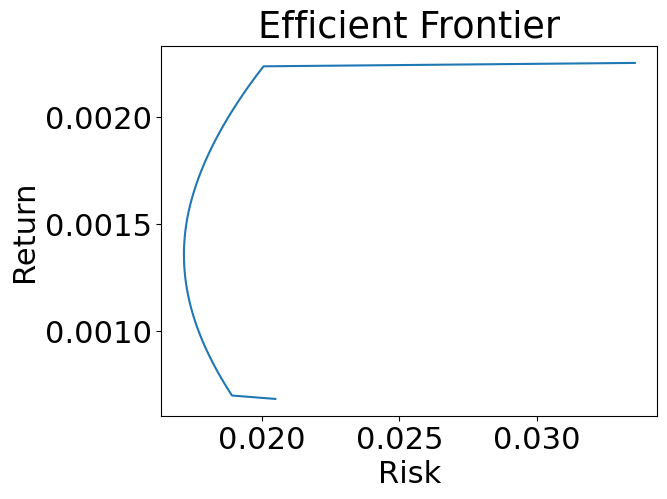

In [32]:
#recheck num stocks
stocks = df.columns
print(stocks)
num_stocks=len(stocks)
print(num_stocks)

# sum statistics
stock_volatility = df.std()
stock_return = df.mean()
cov_mat=df.cov()

#min and max returns range
print(f"Min achievable return: {stock_return.min():.6f}")
print(f"Max achievable return: {stock_return.max():.6f}")

#different return v risk to compare (within possible range)
returns = np.linspace(stock_return.min(), stock_return.max(), 100)
ret_list = []
risks = []
props = []

for ret in returns:
    m = Model("Portfolio_Optimization")
    m.setParam('OutputFlag', 0)
    vars=pd.Series(m.addVars(stocks,lb=0), index=stocks) 
    portfolio_risk = cov_mat.dot(vars).dot(vars)
    m.setObjective(portfolio_risk, GRB.MINIMIZE)
    m.addConstr(vars.sum() == 1, name = 'allocation')
    m.addConstr(stock_return.dot(vars) == ret , name = 'return_sim')
  
    m.optimize()  
    risks.append(np.sqrt(m.objval))
    ret_list.append(stock_return.dot(m.x))
    props.append(m.x)
    

#Basic Visual
plt.rcParams.update({'font.size': 22})
plt.plot(risks, returns) 
plt.xlabel('Risk')
plt.ylabel('Return')
plt.title('Efficient Frontier')
plt.show()

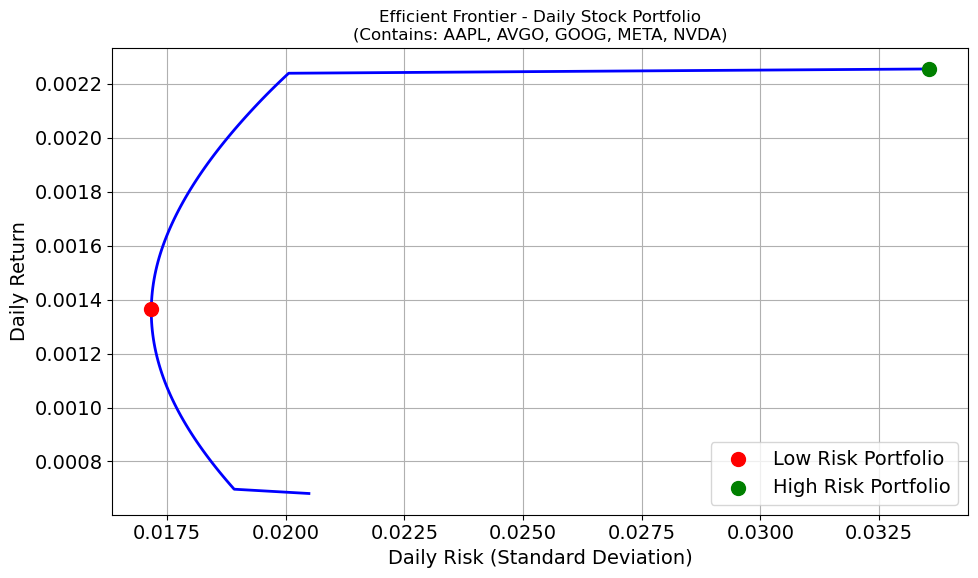

In [39]:
#Detailed Visualization

# Find min risk and max return portfolio indices
min_risk_idx = np.argmin(risks)
max_risk_idx = np.argmax(risks)

plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(10, 6))

# Main frontier line
ax.plot(risks, ret_list, color='blue', linewidth=2)

# Red dot - Low Risk Portfolio (minimum risk point)
ax.scatter(risks[min_risk_idx], ret_list[min_risk_idx], 
           color='red', s=100, zorder=5, label='Low Risk Portfolio')

# Green dot - High Risk Portfolio (max risk/return point)
ax.scatter(risks[max_risk_idx], ret_list[max_risk_idx], 
           color='green', s=100, zorder=5, label='High Risk Portfolio')

# Labels and formatting
ax.set_xlabel('Daily Risk (Standard Deviation)')
ax.set_ylabel('Daily Return')
ax.set_title('Efficient Frontier - Daily Stock Portfolio\n' + 
             f'(Contains: {", ".join(stocks)})', fontsize=12)

ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

In [34]:
#View Min and Max Risk Portfolios

# Extract weights for min risk and max risk/return portfolios
min_risk_weights = pd.Series(props[min_risk_idx], index=stocks)
max_risk_weights = pd.Series(props[max_risk_idx], index=stocks)

print("=" * 40)
print("LOW RISK PORTFOLIO (Minimum Variance)")
print("=" * 40)
for stock, weight in min_risk_weights.items():
    print(f"  {stock}: {weight:.2%}")
print(f"  Expected Return:    {ret_list[min_risk_idx]:.4f}")
print(f"  Expected Risk (SD): {risks[min_risk_idx]:.4f}")

print()
print("=" * 40)
print("HIGH RISK PORTFOLIO (Maximum Risk/Return)")
print("=" * 40)
for stock, weight in max_risk_weights.items():
    print(f"  {stock}: {weight:.2%}")
print(f"  Expected Return:    {ret_list[max_risk_idx]:.4f}")
print(f"  Expected Risk (SD): {risks[max_risk_idx]:.4f}")

LOW RISK PORTFOLIO (Minimum Variance)
  AAPL: 37.46%
  AVGO: 0.00%
  GOOG: 43.40%
  META: 19.14%
  NVDA: 0.00%
  Expected Return:    0.0014
  Expected Risk (SD): 0.0172

HIGH RISK PORTFOLIO (Maximum Risk/Return)
  AAPL: 0.00%
  AVGO: 100.00%
  GOOG: 0.00%
  META: 0.00%
  NVDA: 0.00%
  Expected Return:    0.0023
  Expected Risk (SD): 0.0336


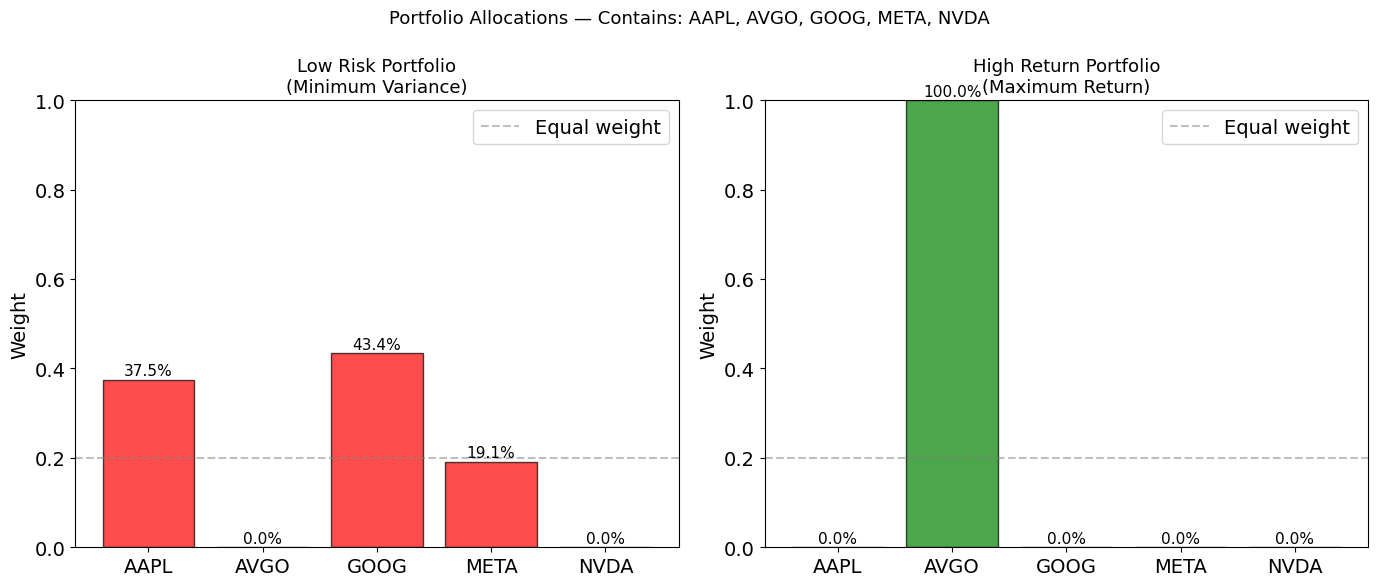

In [35]:
# Visual Comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Min risk portfolio
bars1 = ax1.bar(stocks, min_risk_weights, color='red', alpha=0.7, edgecolor='black')
ax1.set_title('Low Risk Portfolio\n(Minimum Variance)', fontsize=13)
ax1.set_ylabel('Weight')
ax1.set_ylim(0, 1)
ax1.axhline(y=1/num_stocks, color='gray', linestyle='--', alpha=0.5, label='Equal weight')
for bar, weight in zip(bars1, min_risk_weights):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{weight:.1%}', ha='center', fontsize=11)

# Max return portfolio
bars2 = ax2.bar(stocks, max_risk_weights, color='green', alpha=0.7, edgecolor='black')
ax2.set_title('High Return Portfolio\n(Maximum Return)', fontsize=13)
ax2.set_ylabel('Weight')
ax2.set_ylim(0, 1)
ax2.axhline(y=1/num_stocks, color='gray', linestyle='--', alpha=0.5, label='Equal weight')
for bar, weight in zip(bars2, max_risk_weights):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{weight:.1%}', ha='center', fontsize=11)

ax1.legend()
ax2.legend()
plt.suptitle(f'Portfolio Allocations — Contains: {", ".join(stocks)}', fontsize=13)
plt.tight_layout()
plt.show()